# “Employee Attrition Prediction using Decision Trees and Random Forest”

* Question 1 Can employee characteristics predict whether an employee is likely to leave the company?
* Question 2 Which workplace factors contribute most to employee attrition?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [2]:
hr = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
hr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
hr['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

## Attrition Distribution 

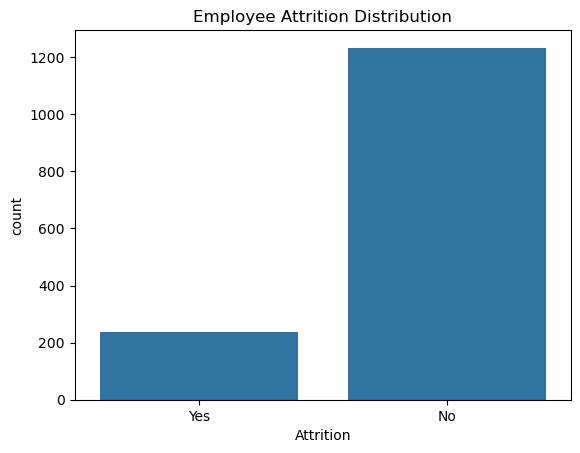

In [8]:
sns.countplot(
    x='Attrition',
    data=hr
)

plt.title('Employee Attrition Distribution')
plt.show()

## Overtime vs Attrition

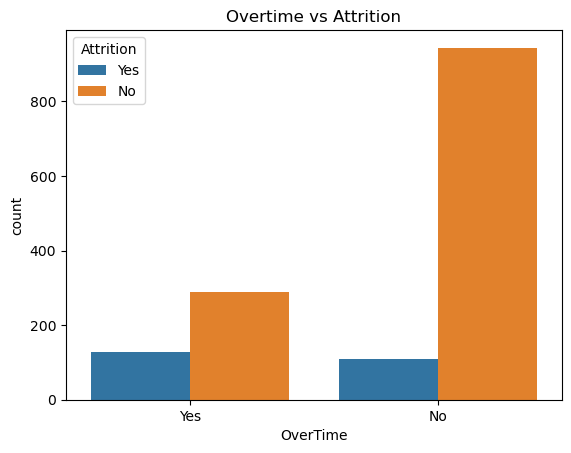

In [9]:
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=hr
)

plt.title('Overtime vs Attrition')

plt.show()

## Monthly Income vs Attrition

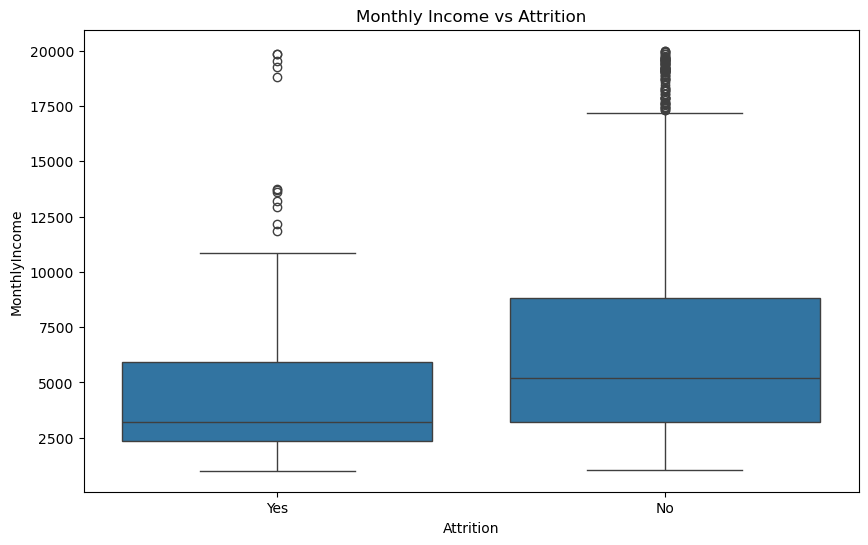

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=hr
)

plt.title('Monthly Income vs Attrition')

plt.show()

## Job Satisfaction vs Attrition

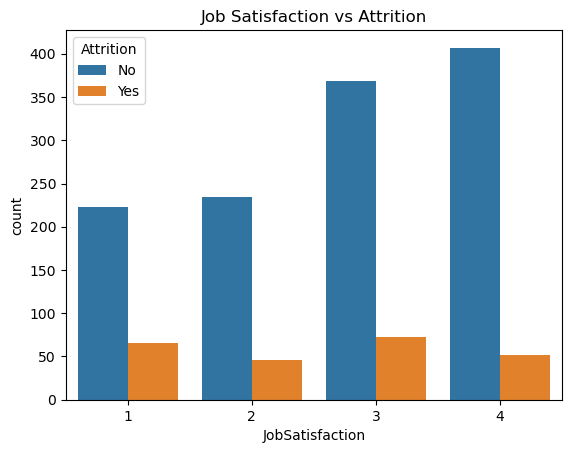

In [11]:
sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=hr
)

plt.title('Job Satisfaction vs Attrition')
plt.show()

## Years at company vs Attrition

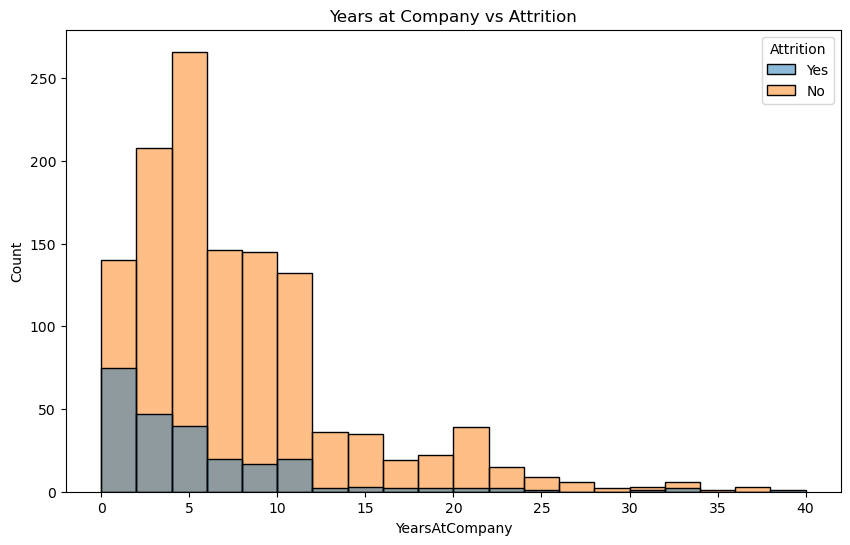

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=hr,
    x='YearsAtCompany',
    hue='Attrition',
    bins=20
)

plt.title('Years at Company vs Attrition')

plt.show()

## Data Preprocessing

In [13]:
hr = pd.get_dummies(hr,drop_first=True)

In [14]:
X = hr.drop('Attrition_Yes',axis=1)
y = hr['Attrition_Yes']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)

## Decision Tree Classifier

In [16]:
tree_model = DecisionTreeClassifier(random_state=42)

In [17]:
tree_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
tree_predictions = tree_model.predict(
    X_test
)

## Confusion Matrix , Classification report , Accuracy score

In [20]:
print(confusion_matrix(y_test,tree_predictions))

[[323  57]
 [ 38  23]]


In [21]:
print(classification_report(y_test,tree_predictions))

              precision    recall  f1-score   support

       False       0.89      0.85      0.87       380
        True       0.29      0.38      0.33        61

    accuracy                           0.78       441
   macro avg       0.59      0.61      0.60       441
weighted avg       0.81      0.78      0.80       441



In [19]:
print(accuracy_score(y_test,tree_predictions))

0.7845804988662132


## Random Forrest Model

In [22]:
forest_model = RandomForestClassifier(n_estimators=200,random_state=42)

forest_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
forest_predictions = forest_model.predict(
    X_test
)

## Confusion Matrix , Classification report , Accuracy score

In [24]:
print(confusion_matrix(y_test,forest_predictions))

[[378   2]
 [ 56   5]]


In [25]:
print(classification_report(y_test,forest_predictions))

              precision    recall  f1-score   support

       False       0.87      0.99      0.93       380
        True       0.71      0.08      0.15        61

    accuracy                           0.87       441
   macro avg       0.79      0.54      0.54       441
weighted avg       0.85      0.87      0.82       441



In [26]:
print(accuracy_score(y_test,forest_predictions))

0.8684807256235828


## Feature Importance

In [27]:
importance = pd.Series(forest_model.feature_importances_,index=X.columns)

importance.sort_values(ascending=False).head(10)

MonthlyIncome        0.077068
Age                  0.055964
OverTime_Yes         0.053897
TotalWorkingYears    0.051742
DailyRate            0.045246
EmployeeNumber       0.044772
MonthlyRate          0.044252
HourlyRate           0.043142
DistanceFromHome     0.038609
YearsAtCompany       0.037095
dtype: float64

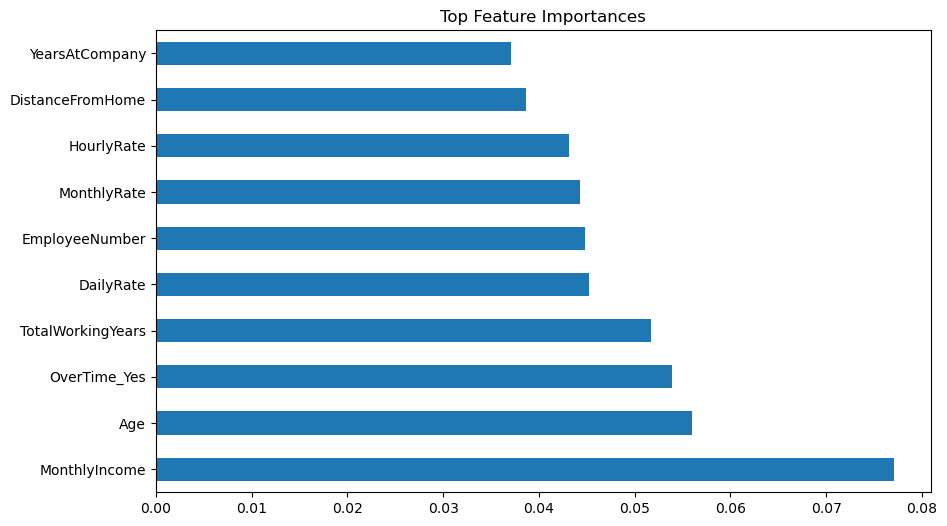

In [28]:
top_features = importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

top_features.plot(kind='barh')

plt.title('Top Feature Importances')

plt.show()

## Final Business Insights
* Overtime is one of the strongest drivers of employee attrition.
* Employees with lower job satisfaction show higher turnover risk.
* Compensation and work-life balance significantly affect retention.
* Short-tenure employees are more vulnerable to leaving.
* Random Forest improved prediction performance by combining multiple decision trees.